In [47]:
# Parameters
year = 2021  # default value
import papermill as pm

notebook_path = "your_analysis_notebook.ipynb"

for year in range(2021, 2021):
    output_notebook = f"output_analysis_{year}.ipynb"
    print(f"Running notebook for year {year}...")
    pm.execute_notebook(
        notebook_path,
        output_notebook,
        parameters={"year": year}
    )
    print(f"Finished {year}\n")


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import numpy as np


Cleaning Data

In [ ]:
from pathlib import Path

source_file = (
    Path("kaggle")
    / "input"
    / "valorant-champion-tour-2021-2023-data"
    / "vct_2024"
    / "agents"
    / "teams_picked_agents.csv"
)
data = pd.read_csv(source_file)
data['Win Rate'] = data['Total Wins By Map'] / data['Total Maps Played']
data['Win Rate'] = data['Win Rate'].fillna(0)
data['Win'] = (data['Total Wins By Map'] > data['Total Loss By Map']).astype(int)
cleaned_data = (
    data.groupby(['Tournament', 'Stage', 'Match Type', 'Map', 'Team'])
    .agg({
        'Agent': lambda x: ', '.join(sorted(x)),
        'Win': 'max'
    })
    .reset_index()
)
cleaned_data.rename(columns={'Agent': 'Agents Played', 'Win': 'Match Outcome'}, inplace=True)
cleaned_data.to_csv('cleaned_match_data.csv', index=False)
cleaned_data.head()

,Tournament,Stage,Match Type,Map,Team,Agents Played,Match Outcome
0,Champions Tour 2024: Americas Kickoff,All Stages,All Match Types,Ascent,Cloud9,"jett, kayo, killjoy, omen, sova",0
1,Champions Tour 2024: Americas Kickoff,All Stages,All Match Types,Ascent,Evil Geniuses,"cypher, jett, kayo, omen, sova",1
2,Champions Tour 2024: Americas Kickoff,All Stages,All Match Types,Ascent,FURIA,"jett, kayo, killjoy, omen, sova",0
3,Champions Tour 2024: Americas Kickoff,All Stages,All Match Types,Ascent,G2 Esports,"cypher, jett, kayo, omen, viper",1
4,Champions Tour 2024: Americas Kickoff,All Stages,All Match Types,Ascent,KRÜ Esports,"jett, kayo, killjoy, omen, sova",0


Statistics Summary

In [37]:
file_path = 'cleaned_match_data.csv'
data = pd.read_csv(file_path)

data['Agents Played'] = data['Agents Played'].apply(lambda x: x.split(', '))

tournament_summary = data['Tournament'].value_counts()
map_summary = data['Map'].value_counts()
stage_summary = data['Stage'].value_counts()
match_type_summary = data['Match Type'].value_counts()

print("=== Descriptive Statistics Summary ===")
print("\n1. Number of Matches per Tournament:")
print(tournament_summary)

print("\n2. Number of Matches per Map:")
print(map_summary)

print("\n3. Distribution of Stages:")
print(stage_summary)

print("\n4. Distribution of Match Types:")
print(match_type_summary)

=== Descriptive Statistics Summary ===

1. Number of Matches per Tournament:
Tournament
Champions Tour 2024: EMEA Stage 1        257
Champions Tour 2024: China Stage 1       253
Valorant Champions 2024                  252
Champions Tour 2024: Pacific Stage 1     249
Champions Tour 2024: Americas Stage 1    248
Champions Tour 2024: Pacific Stage 2     239
Champions Tour 2024: Americas Stage 2    231
Champions Tour 2024: EMEA Stage 2        227
Champions Tour 2024: China Stage 2       217
Champions Tour 2024: Masters Shanghai    190
Champions Tour 2024: Americas Kickoff    149
Champions Tour 2024: China Kickoff       144
Champions Tour 2024: Pacific Kickoff     140
Champions Tour 2024: EMEA Kickoff        139
Champions Tour 2024: Masters Madrid      131
Name: count, dtype: int64

2. Number of Matches per Map:
Map
Lotus     523
Sunset    495
Icebox    457
Bind      414
Ascent    396
Split     334
Breeze    241
Haven     137
Abyss      69
Name: count, dtype: int64

3. Distribution of Stag

notebook_cell.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tournament_summary.index, y=tournament_summary.values, palette="coolwarm", ax=ax[0])
notebook_cell.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=map_summary.index, y=map_summary.values, palette="coolwarm", ax=ax[1])


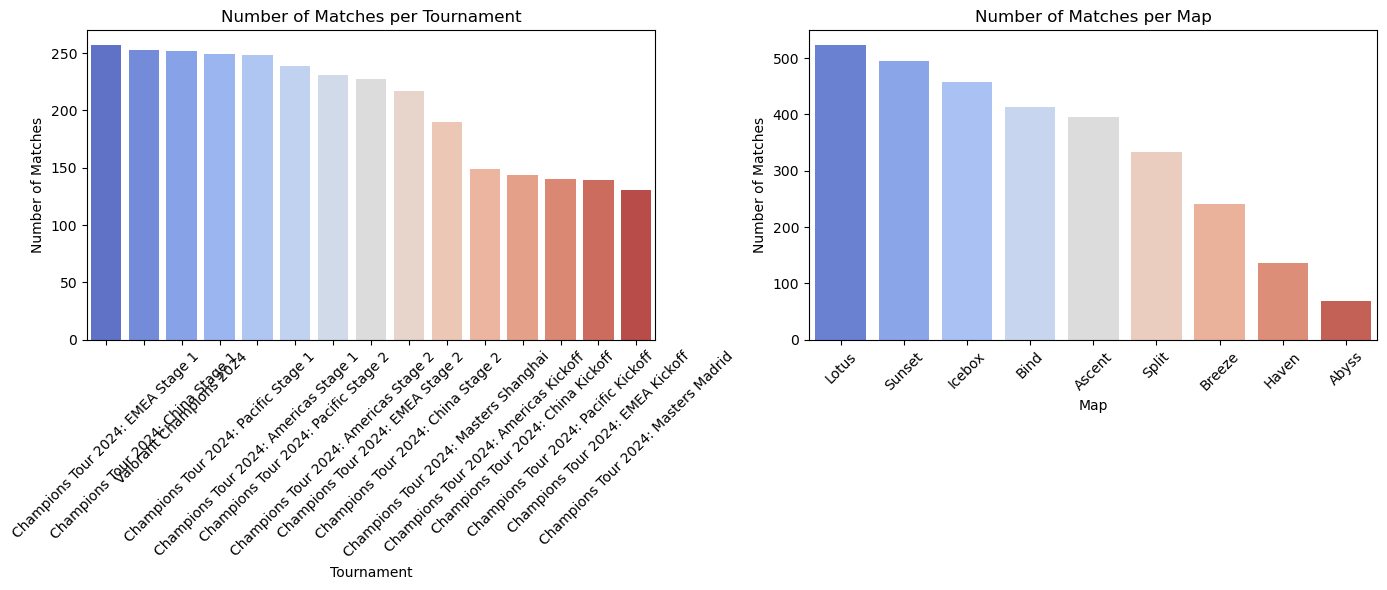

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=tournament_summary.index, y=tournament_summary.values, palette="coolwarm", ax=ax[0])
ax[0].set_title("Number of Matches per Tournament")
ax[0].set_xlabel("Tournament")
ax[0].set_ylabel("Number of Matches")
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(x=map_summary.index, y=map_summary.values, palette="coolwarm", ax=ax[1])
ax[1].set_title("Number of Matches per Map")
ax[1].set_xlabel("Map")
ax[1].set_ylabel("Number of Matches")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Match Outcome Distribution

notebook_cell.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Match Outcome', palette="coolwarm")


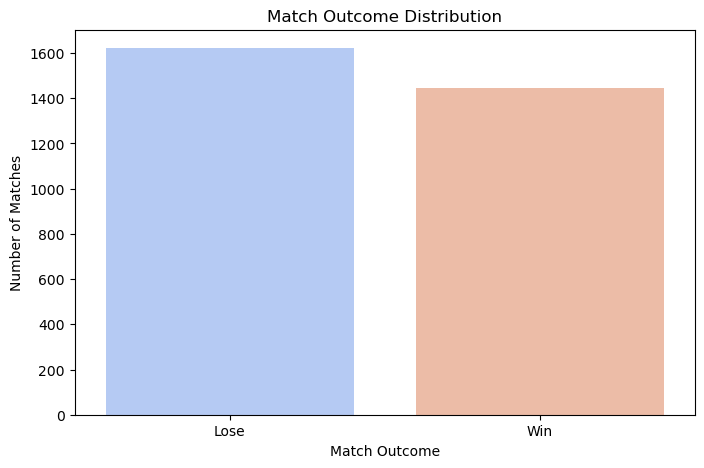

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Match Outcome', palette="coolwarm")
plt.title("Match Outcome Distribution")
plt.xlabel("Match Outcome")
plt.ylabel("Number of Matches")
plt.xticks([0, 1], ['Lose', 'Win'])
plt.show()

Match Outcome Distribution by Map

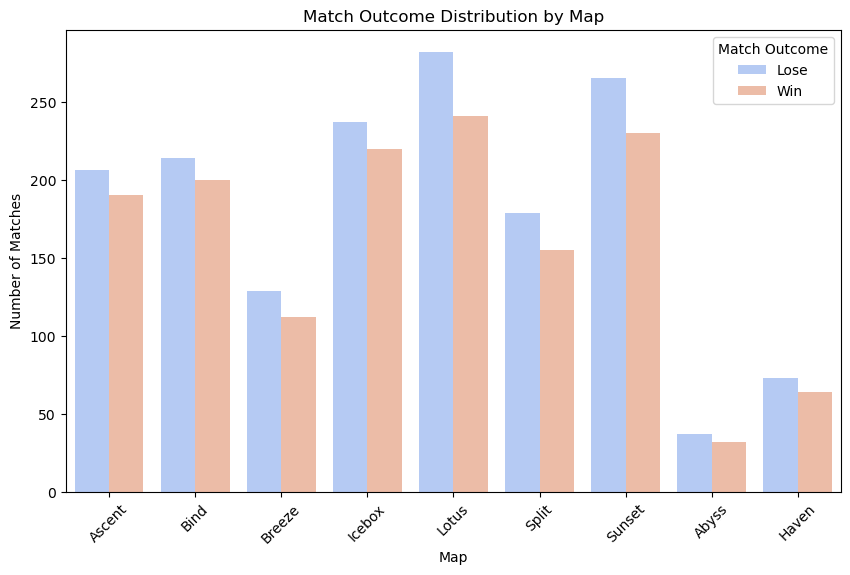

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Map', hue='Match Outcome', palette="coolwarm")
plt.title("Match Outcome Distribution by Map")
plt.xlabel("Map")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.legend(title="Match Outcome", labels=["Lose", "Win"])
plt.show()


Winrate Per Agent

notebook_cell.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agent_winrate.index, y=agent_winrate.values, palette="coolwarm")


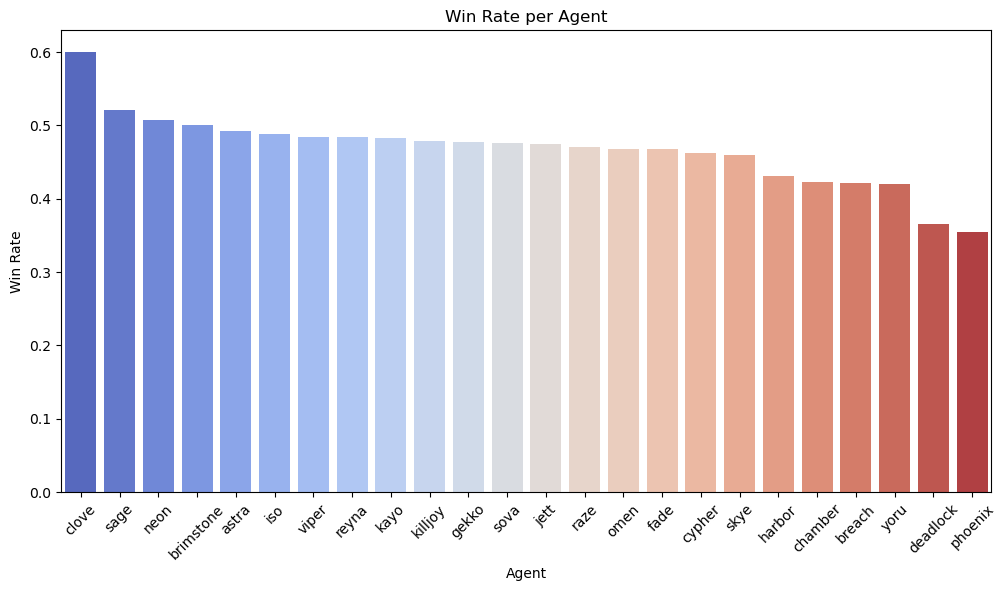

In [41]:
mlb = MultiLabelBinarizer()
agents_df = pd.DataFrame(mlb.fit_transform(data['Agents Played']), columns=mlb.classes_, index=data.index)
agent_winrate = agents_df.mul(data['Match Outcome'], axis=0).sum() / agents_df.sum()

plt.figure(figsize=(12, 6))
agent_winrate = agent_winrate.sort_values(ascending=False)
sns.barplot(x=agent_winrate.index, y=agent_winrate.values, palette="coolwarm")
plt.title("Win Rate per Agent")
plt.xlabel("Agent")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()


Heatmap of Agent Correlations

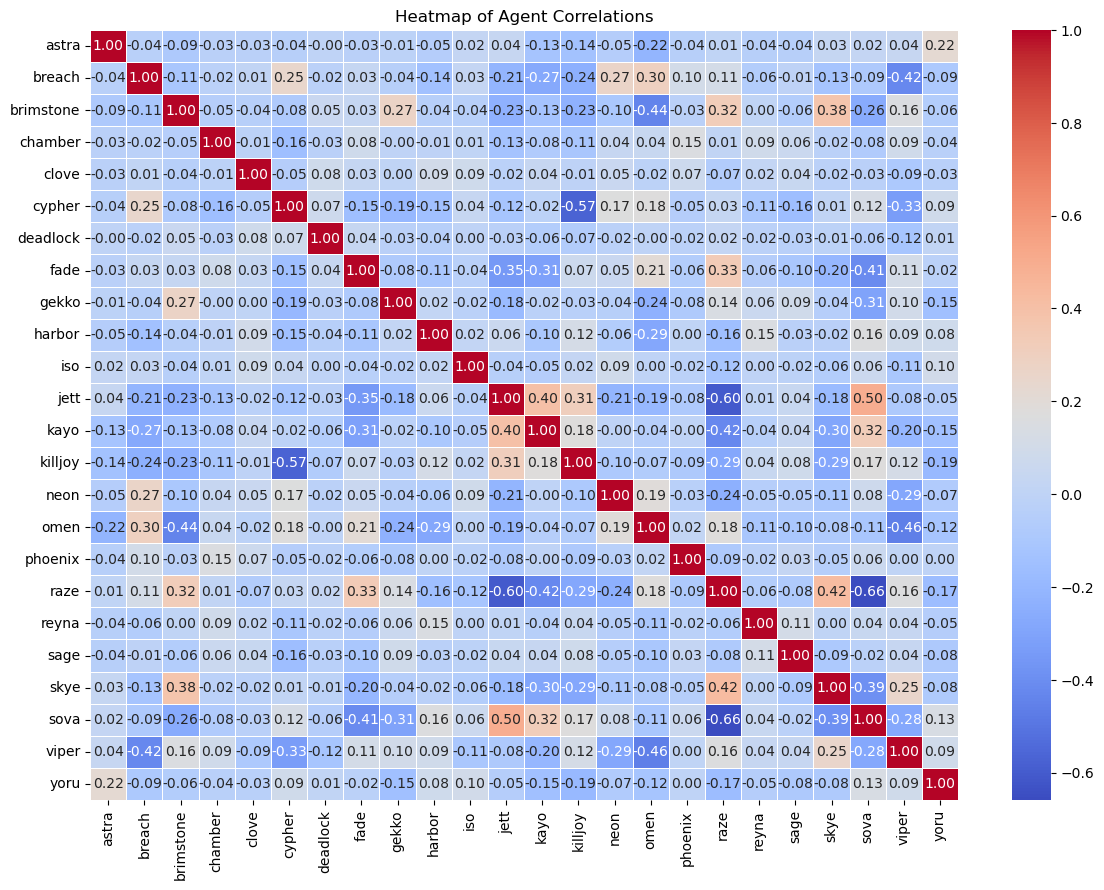

In [42]:
agent_match_data = pd.concat([agents_df, data['Match Outcome']], axis=1)
correlation_matrix = agent_match_data.corr()
agent_correlation = correlation_matrix.loc[agents_df.columns, agents_df.columns]

plt.figure(figsize=(14, 10))
sns.heatmap(agent_correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Agent Correlations")
plt.show()


Frequency Agents Pick

notebook_cell.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agent_pick_freq.index, y=agent_pick_freq.values, palette="coolwarm")


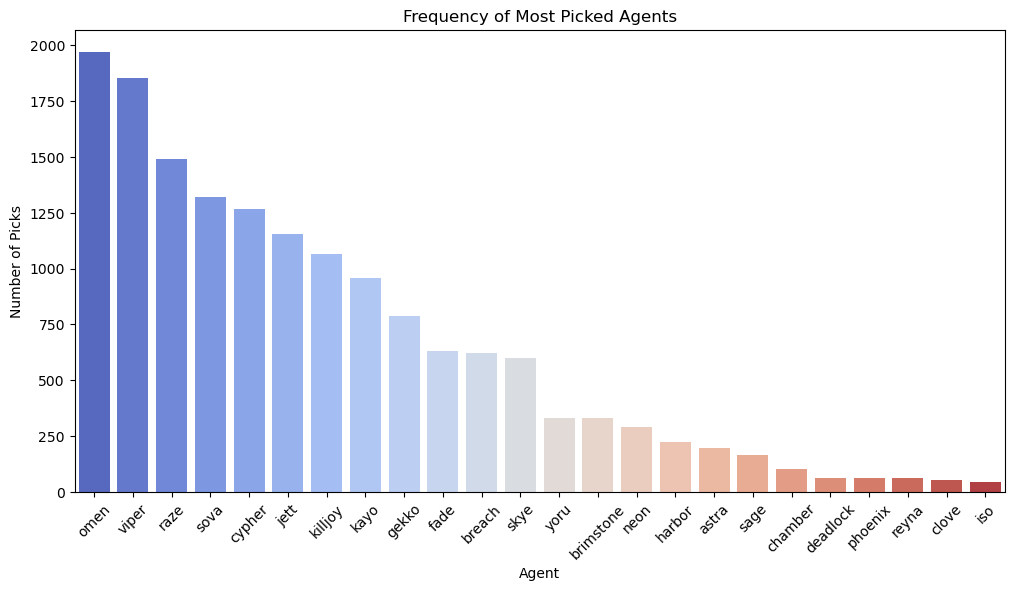

In [43]:
agent_pick_freq = agents_df.sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=agent_pick_freq.index, y=agent_pick_freq.values, palette="coolwarm")
plt.title("Frequency of Most Picked Agents")
plt.xlabel("Agent")
plt.ylabel("Number of Picks")
plt.xticks(rotation=45)
plt.show()

 Meta Agent Impact Analysis on Win Probability

notebook_cell.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Agent', y='Pick Rate (%)', data=meta_analysis, palette="coolwarm", ax=ax1)


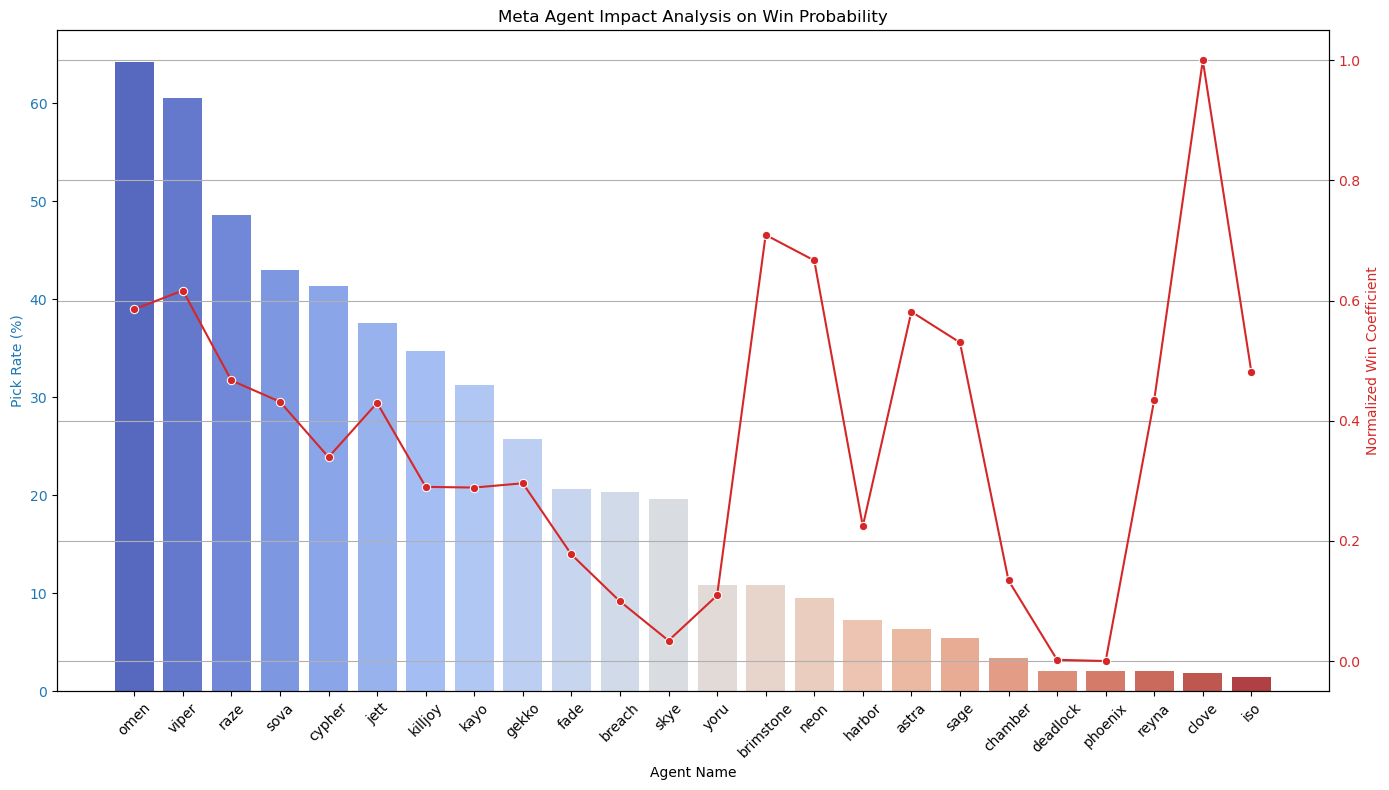

In [44]:
X = agents_df
y = data['Match Outcome']

reg_model = LinearRegression()
reg_model.fit(X, y)

agent_coefficients = pd.Series(reg_model.coef_, index=agents_df.columns)

scaler = MinMaxScaler()
normalized_coefficients = scaler.fit_transform(agent_coefficients.values.reshape(-1, 1))

pick_rate = agents_df.sum(axis=0) / len(agents_df) * 100

meta_analysis = pd.DataFrame({
    'Agent': agents_df.columns,
    'Pick Rate (%)': pick_rate.values,
    'Normalized Win Coefficient': normalized_coefficients.flatten()
}).sort_values(by='Pick Rate (%)', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 8))

color = 'tab:blue'
ax1.set_xlabel('Agent Name')
ax1.set_ylabel('Pick Rate (%)', color=color)
sns.barplot(x='Agent', y='Pick Rate (%)', data=meta_analysis, palette="coolwarm", ax=ax1)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Normalized Win Coefficient', color=color)
sns.lineplot(x='Agent', y='Normalized Win Coefficient', data=meta_analysis, color=color, marker='o', ax=ax2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Meta Agent Impact Analysis on Win Probability")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Map and Agents Composition Winning Prediction

In [45]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def predict_win(map_input, agent_input):
    input_data = pd.DataFrame(0, index=[0], columns=X.columns)
    
    map_column = f"Map_{map_input}"
    if map_column in input_data.columns:
        input_data[map_column] = 1
    
    for agent in agent_input:
        if agent in input_data.columns:
            input_data[agent] = 1

    prediction = reg_model.predict(input_data)[0]
    win_percentage = sigmoid(prediction) * 100
    return win_percentage

map_input = "Ascent" #change the map
agents_input = "Sova", "Iso", "Killjoy", "Jett", "Cypher" #change agents composition
agents_input = [agent_input.lower() for agent_input in agents_input]
win_percentage = predict_win(map_input, agents_input)

print(f"Win probability for map '{map_input}' with agents {agents_input}: {win_percentage:.2f}%")

Win probability for map 'Ascent' with agents ['sova', 'iso', 'killjoy', 'jett', 'cypher']: 61.17%


Meta Recommendations on Each Maps based on Win Rate and Pick Rate

In [46]:
map_recommendations = {}
valid_maps = data['Map'].unique()
combined_data = data
for map_name in valid_maps:
    map_data = combined_data[combined_data['Map'] == map_name]
    
    pick_rate = agents_df.loc[map_data.index].sum() / len(map_data)
    
    win_rate = agents_df.loc[map_data.index].mul(map_data['Match Outcome'], axis=0).sum() / agents_df.loc[map_data.index].sum()
    
    agent_stats = pd.DataFrame({
        'Pick Rate': pick_rate,
        'Win Rate': win_rate
    }).fillna(0)
    
    reg_model = LinearRegression()
    reg_model.fit(agent_stats[['Pick Rate']], agent_stats['Win Rate'])
    
    agent_stats['Predicted Win Rate'] = reg_model.predict(agent_stats[['Pick Rate']])
    
    recommended_agents = agent_stats.sort_values(by='Predicted Win Rate', ascending=False).index.tolist()
    
    map_recommendations[map_name] = recommended_agents[:5]

for map_name, agents in map_recommendations.items():
    print(f"Recommended agents for {map_name}: {', '.join(agents)}")


Recommended agents for Ascent: omen, jett, sova, kayo, killjoy
Recommended agents for Bind: raze, viper, brimstone, skye, gekko
Recommended agents for Breeze: viper, sova, cypher, jett, yoru
Recommended agents for Icebox: viper, killjoy, jett, sova, gekko
Recommended agents for Lotus: omen, raze, fade, viper, killjoy
Recommended agents for Split: raze, omen, viper, skye, cypher
Recommended agents for Sunset: omen, cypher, raze, sova, breach
Recommended agents for Abyss: sova, cypher, omen, jett, kayo
Recommended agents for Haven: omen, sova, breach, cypher, jett
